# 02 · Feature Engineering

Builds the model-ready feature table from `players_master.csv` (notebook 01) plus
`appearances.csv` and `transfers.csv`.

Feature groups:
- **Player attributes** — age, height, foot, position, nationality
- **Performance (last season)** — goals, assists, minutes, appearances, cards, per-90 rates
- **Market/contract signals** — prior transfer fees, transfer count, contract time remaining
- **Club context** — club's total market value, squad average age, competition

> Requires `appearances.csv` and `transfers.csv` in `../data/raw/`.


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")

master = pd.read_csv(PROCESSED / "players_master.csv",
                      parse_dates=["date_of_birth", "valuation_date"] +
                                  (["contract_expiration_date"] if True else []))
appearances = pd.read_csv(RAW / "appearances.csv", parse_dates=["date"])
transfers = pd.read_csv(RAW / "transfers.csv", parse_dates=["transfer_date"])

print("master:      ", master.shape)
print("appearances: ", appearances.shape)
print("transfers:   ", transfers.shape)


master:       (41528, 46)
appearances:  (1894350, 13)
transfers:    (175165, 10)


## 1. Age at valuation date\n\nRecomputed here (also done in notebook 01) so this notebook can run standalone.

In [3]:
master["age"] = (master["valuation_date"] - master["date_of_birth"]).dt.days / 365.25
master["age"] = master["age"].round(2)
master[["name", "date_of_birth", "valuation_date", "age"]].head()


,name,date_of_birth,valuation_date,age
0,Miroslav Klose,1978-06-09,2016-01-04,37.57
1,Roman Weidenfeller,1980-08-06,2017-12-28,37.39
2,Dimitar Berbatov,1981-01-30,2016-06-21,35.39
3,Lúcio,1978-05-08,2016-11-15,38.52
4,Tom Starke,1981-03-18,2018-06-05,37.22


## 2. Last-season performance stats

For each player we look at appearances in the **365 days before their valuation date** —
this approximates "last season" without needing to hardcode season labels, and keeps the
feature consistent even though different players were valued on different dates.


In [4]:
LOOKBACK_DAYS = 365

app = appearances.merge(master[["player_id", "valuation_date"]], on="player_id", how="inner")
app["days_before_valuation"] = (app["valuation_date"] - app["date"]).dt.days
last_season = app[(app["days_before_valuation"] >= 0) & (app["days_before_valuation"] <= LOOKBACK_DAYS)]

agg = last_season.groupby("player_id").agg(
    last_season_appearances=("minutes_played", "count"),
    last_season_minutes=("minutes_played", "sum"),
    last_season_goals=("goals", "sum"),
    last_season_assists=("assists", "sum"),
    last_season_yellow_cards=("yellow_cards", "sum"),
    last_season_red_cards=("red_cards", "sum"),
).reset_index()

# per-90 rates (avoid divide-by-zero for players with 0 minutes)
minutes_90 = (agg["last_season_minutes"] / 90).replace(0, np.nan)
agg["goals_per_90"] = (agg["last_season_goals"] / minutes_90).fillna(0)
agg["assists_per_90"] = (agg["last_season_assists"] / minutes_90).fillna(0)
agg["goal_contributions"] = agg["last_season_goals"] + agg["last_season_assists"]

print(f"Players with >=1 appearance in lookback window: {agg.shape[0]:,} / {master.shape[0]:,}")
agg.head()


Players with >=1 appearance in lookback window: 14,511 / 41,528


,player_id,last_season_appearances,last_season_minutes,last_season_goals,last_season_assists,last_season_yellow_cards,last_season_red_cards,goals_per_90,assists_per_90,goal_contributions
0,10,36,2429,12,8,6,0,0.444627,0.296418,20
1,26,3,181,0,0,0,0,0.000000,0.000000,0
2,65,22,1150,5,0,2,1,0.391304,0.000000,5
3,80,2,180,0,0,0,0,0.000000,0.000000,0
4,109,14,1219,0,0,1,0,0.000000,0.000000,0


## 3. Transfer history features

In [5]:
tr = transfers.merge(master[["player_id", "valuation_date"]], on="player_id", how="inner")
tr = tr[tr["transfer_date"] <= tr["valuation_date"]]

tr_agg = tr.groupby("player_id").agg(
    num_prior_transfers=("transfer_fee", "count"),
    last_transfer_fee=("transfer_fee", "last"),
    max_transfer_fee=("transfer_fee", "max"),
).reset_index()

tr_agg.head()


,player_id,num_prior_transfers,last_transfer_fee,max_transfer_fee
0,2989,10,250000.0,3500000.0
1,3333,9,0.0,22000000.0
2,4391,13,0.0,3000000.0
3,5336,5,0.0,0.0
4,7161,6,0.0,10000000.0


## 4. Assemble the feature table

In [6]:
features = master.merge(agg, on="player_id", how="left")
features = features.merge(tr_agg, on="player_id", how="left")

perf_cols = ["last_season_appearances", "last_season_minutes", "last_season_goals",
             "last_season_assists", "last_season_yellow_cards", "last_season_red_cards",
             "goals_per_90", "assists_per_90", "goal_contributions"]
transfer_cols = ["num_prior_transfers", "last_transfer_fee", "max_transfer_fee"]
features[perf_cols + transfer_cols] = features[perf_cols + transfer_cols].fillna(0)

if "contract_expiration_date" in features.columns:
    features["contract_years_remaining"] = (
        (features["contract_expiration_date"] - features["valuation_date"]).dt.days / 365.25
    ).clip(lower=0).fillna(0)
else:
    features["contract_years_remaining"] = 0.0

features.shape


(41528, 59)

In [7]:
candidate_cols = {
    "id": ["player_id", "name"],
    "player": ["age", "position", "sub_position", "foot", "height_in_cm", "country_of_citizenship"],
    "club": ["club_name", "club_domestic_competition_id", "club_squad_size",
             "club_average_age", "club_total_market_value"],
    "performance": perf_cols,
    "market": transfer_cols + ["contract_years_remaining"],
    "target": ["current_market_value_eur"],
}

keep = [c for group in candidate_cols.values() for c in group if c in features.columns]
final = features[keep].copy()

print(f"Final feature table: {final.shape[0]:,} rows x {final.shape[1]} cols")
print("\nColumns kept:")
for group, cols in candidate_cols.items():
    present = [c for c in cols if c in features.columns]
    print(f"  {group:12s}: {present}")

final.head()


Final feature table: 41,528 rows x 27 cols

Columns kept:
  id          : ['player_id', 'name']
  player      : ['age', 'position', 'sub_position', 'foot', 'height_in_cm', 'country_of_citizenship']
  club        : ['club_name', 'club_domestic_competition_id', 'club_squad_size', 'club_average_age', 'club_total_market_value']
  performance : ['last_season_appearances', 'last_season_minutes', 'last_season_goals', 'last_season_assists', 'last_season_yellow_cards', 'last_season_red_cards', 'goals_per_90', 'assists_per_90', 'goal_contributions']
  market      : ['num_prior_transfers', 'last_transfer_fee', 'max_transfer_fee', 'contract_years_remaining']
  target      : ['current_market_value_eur']


,player_id,name,age,position,sub_position,foot,height_in_cm,country_of_citizenship,club_name,club_domestic_competition_id,...,last_season_yellow_cards,last_season_red_cards,goals_per_90,assists_per_90,goal_contributions,num_prior_transfers,last_transfer_fee,max_transfer_fee,contract_years_remaining,current_market_value_eur
0,10,Miroslav Klose,37.57,Attack,Centre-Forward,right,184.0,Germany,Società Sportiva Lazio S.p.A.,IT1,...,6.0,0.0,0.444627,0.296418,20.0,0.0,0.0,0.0,0.0,1000000
1,26,Roman Weidenfeller,37.39,Goalkeeper,Goalkeeper,left,190.0,Germany,Borussia Dortmund,L1,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,750000
2,65,Dimitar Berbatov,35.39,Attack,Centre-Forward,NaN,NaN,Bulgaria,Panthessalonikios Athlitikos Omilos Konstantin...,GR1,...,2.0,1.0,0.391304,0.000000,5.0,0.0,0.0,0.0,0.0,1000000
3,77,Lúcio,38.52,Defender,Centre-Back,NaN,NaN,Brazil,Juventus FC,IT1,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,200000
4,80,Tom Starke,37.22,Goalkeeper,Goalkeeper,right,194.0,Germany,Bayern Munich,L1,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,100000


## 5. Sanity check: correlation with target

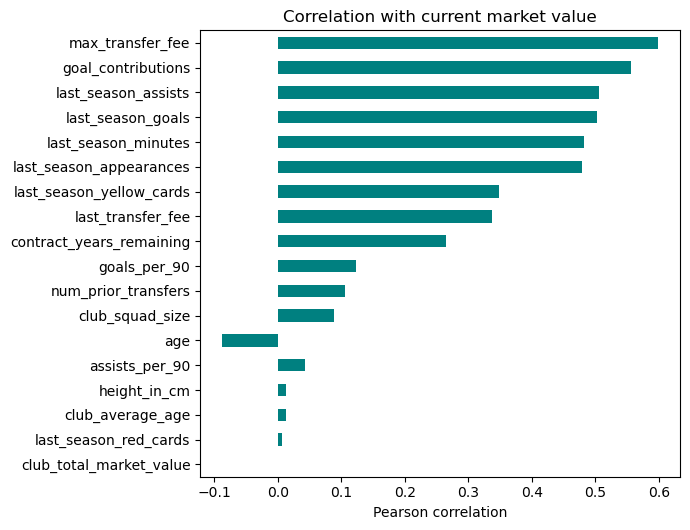

In [8]:
import matplotlib.pyplot as plt

numeric = final.select_dtypes(include=[np.number]).drop(columns=["player_id"], errors="ignore")
corr_with_target = (
    numeric.corr()["current_market_value_eur"]
    .drop("current_market_value_eur")
    .sort_values(key=abs, ascending=False)
)
plt.figure(figsize=(7, max(3, len(corr_with_target) * 0.3)))
corr_with_target.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Correlation with current market value")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()


## 6. Save feature table

In [9]:
out_path = PROCESSED / "features.csv"
final.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")


Saved -> ../data/processed/features.csv
